In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

sc.settings.n_jobs = 8
sc.set_figure_params(figsize=(5,5), dpi_save=300, dpi=100, frameon=False)
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams["font.family"] = "Arial"
%config InlineBackend.figure_format = 'retina'

In [16]:
data = pd.read_excel('../data/Hiplex.xlsx')

In [3]:
cnts = data[['Kcnab1','Kcnc4','Kcnd3','Kcnh5','Kcnq3','Slc2a4']].copy()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
pca = PCA(3)

cnts_pca = pca.fit_transform(scaler.fit_transform(cnts))

In [5]:
results = pd.DataFrame(cnts_pca, columns=['PC1','PC2','PC3'])

In [6]:
from sklearn.cluster import KMeans

kmean = KMeans(6)
results['clusters'] = kmean.fit_predict(scaler.transform(cnts))

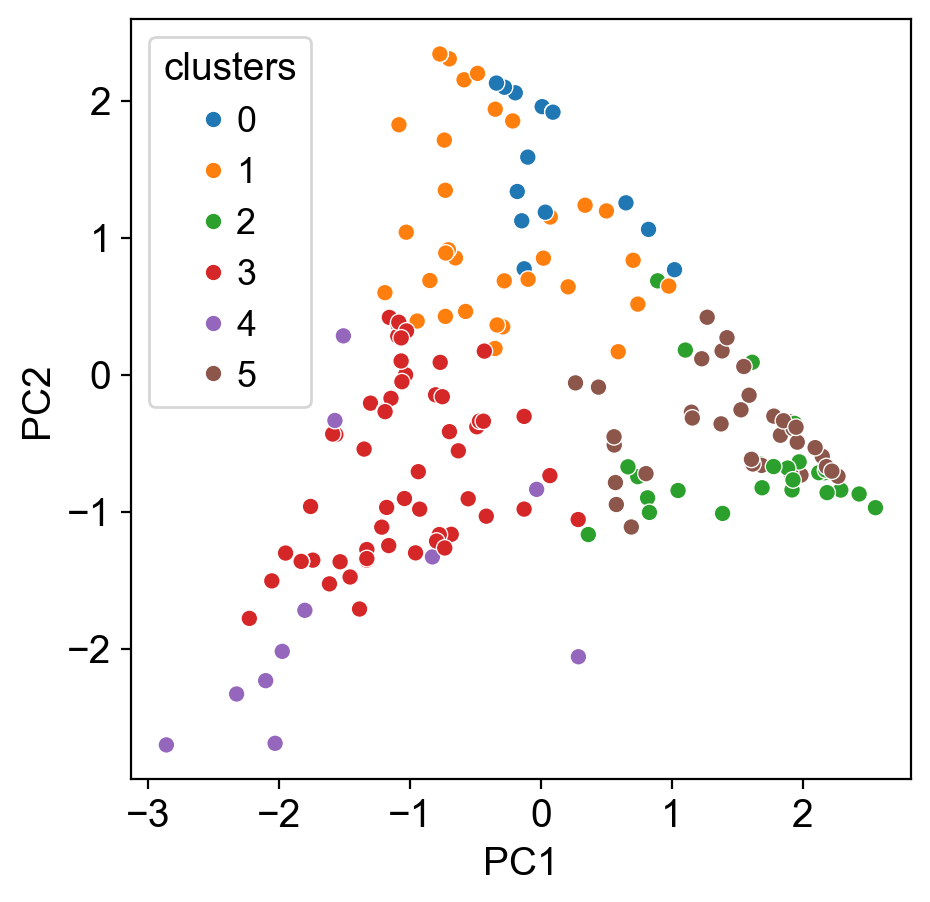

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(results, x='PC1', y='PC2', hue='clusters', palette='tab10', ax=ax)
ax.grid(False)

In [8]:
data['clusters'] = results['clusters'].copy()

In [9]:
data['y_flip'] = data.y * -1

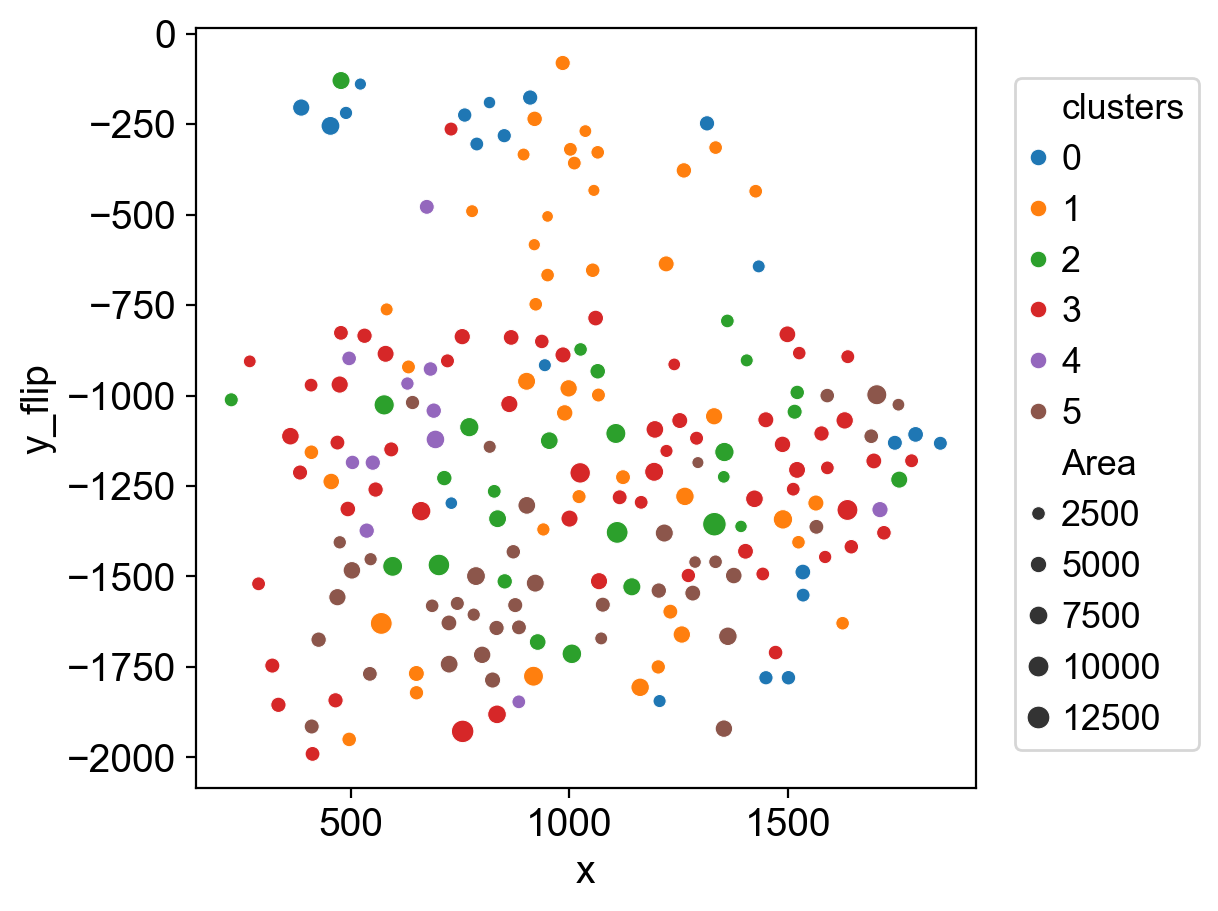

In [10]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data, x='x', y='y_flip', size='Area', hue='clusters', palette='tab10', ax=ax)
ax.legend_.set_loc((1.05,0.05))
ax.grid(False)

/var/folders/pg/_gfvzhnj3zxc0lm8r3cm3jc00000gn/T/ipykernel_20816/471029298.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


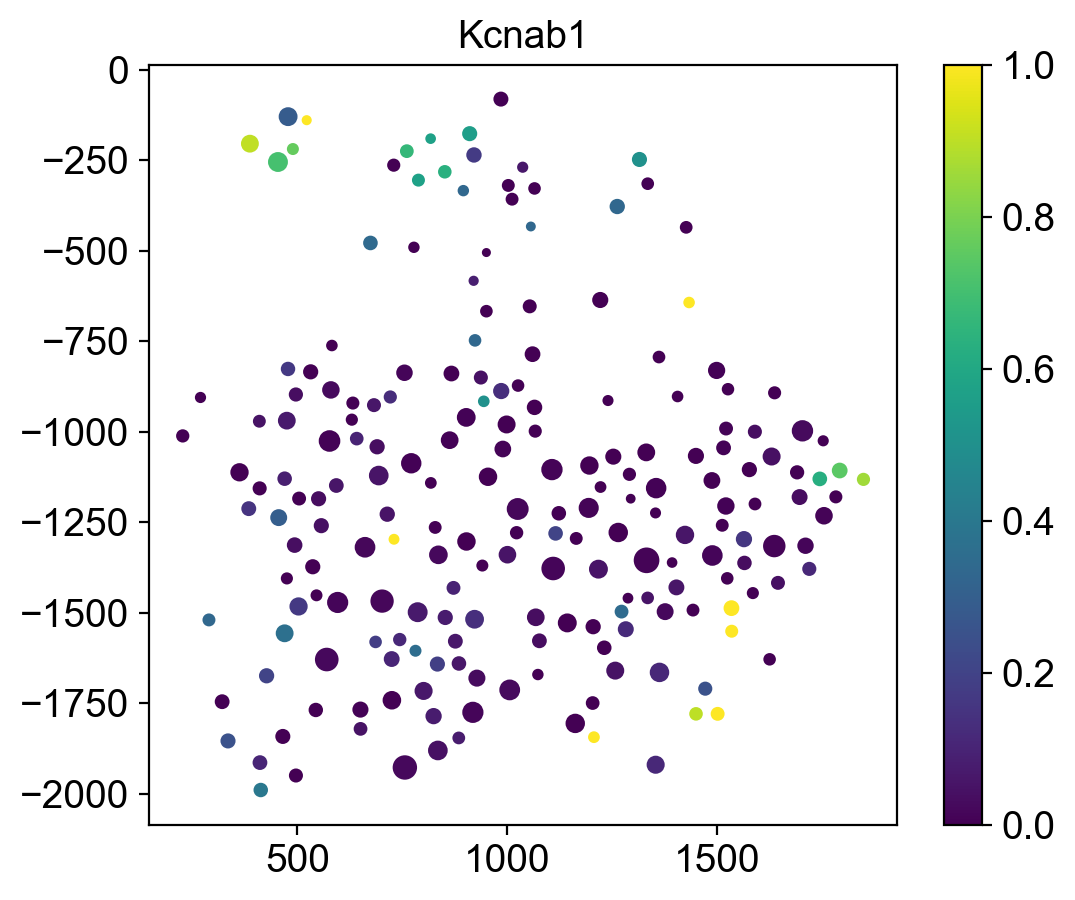

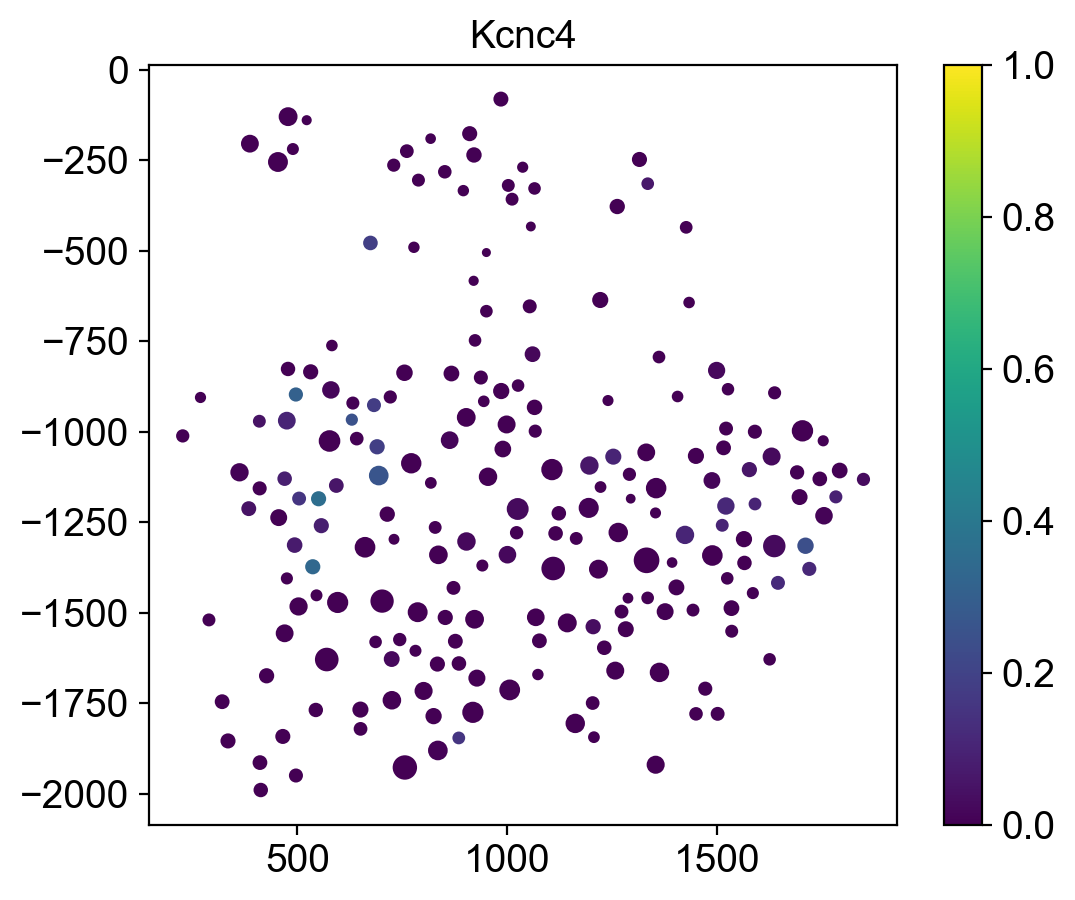

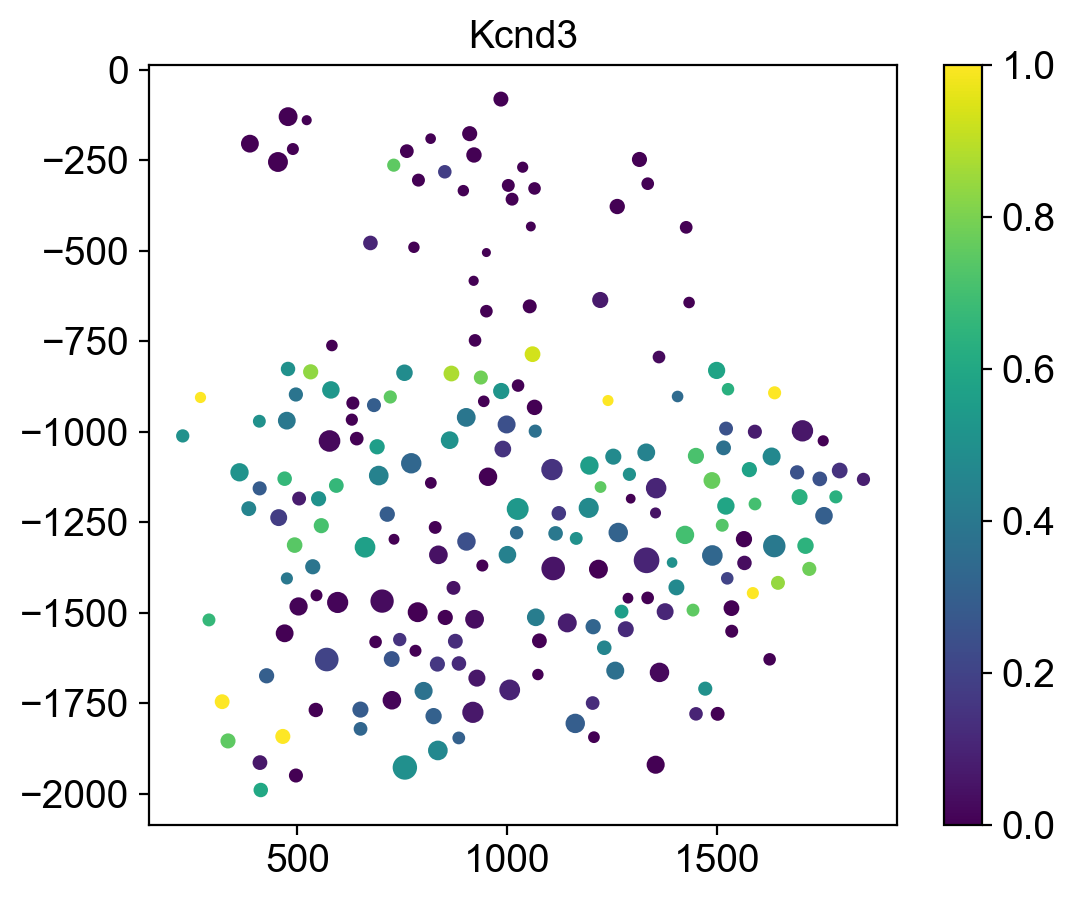

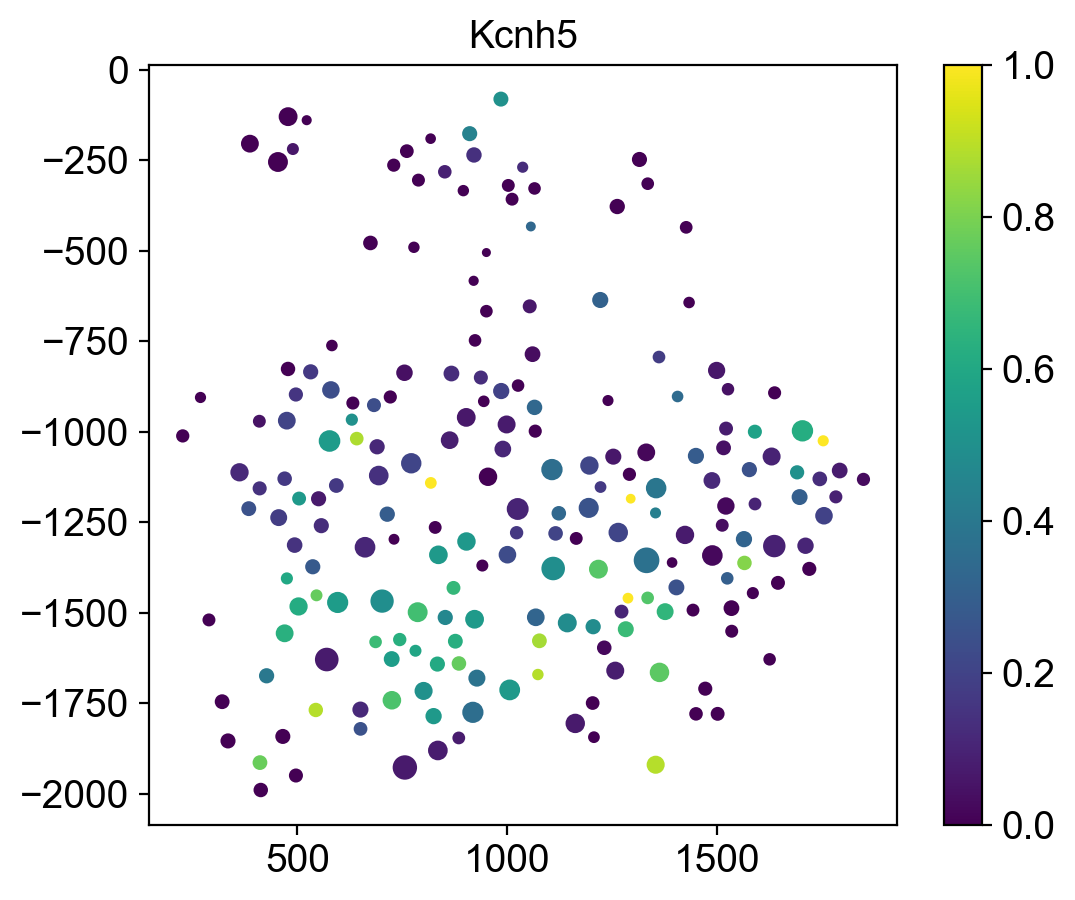

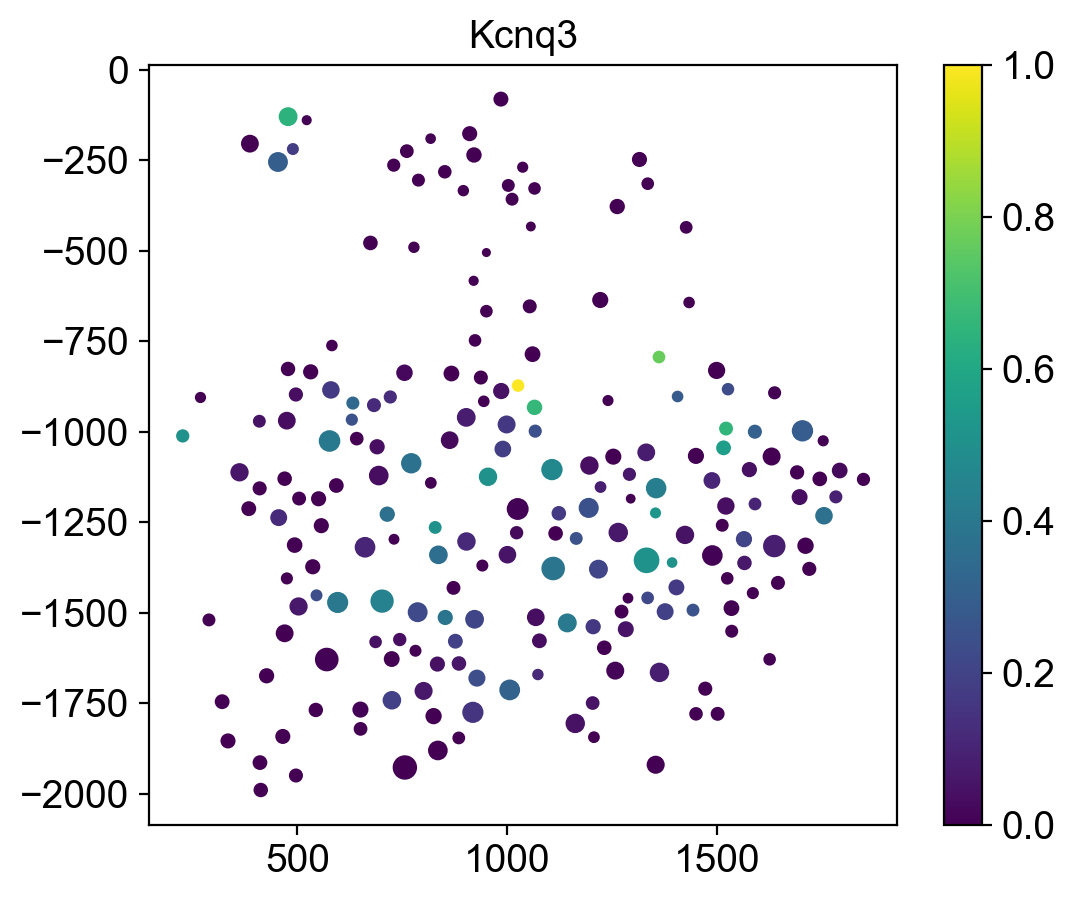

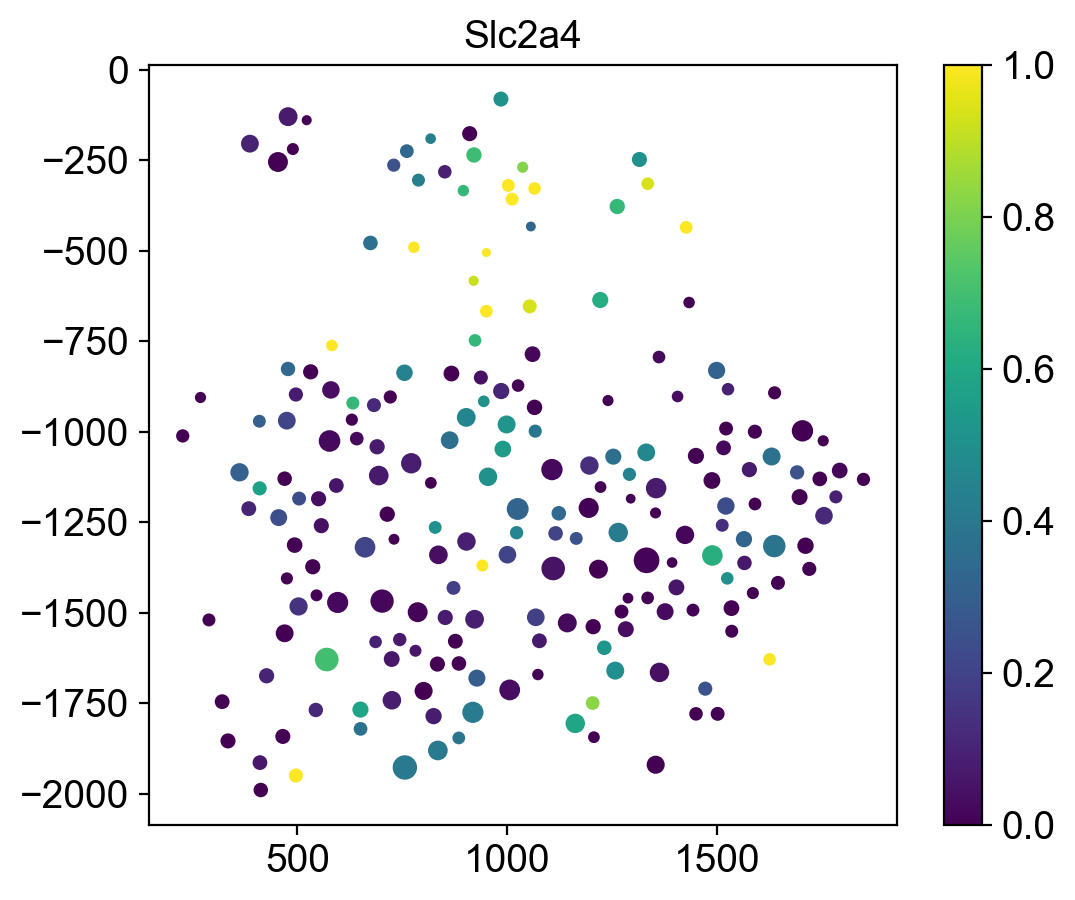

In [ ]:
for g in ['Kcnab1','Kcnc4','Kcnd3','Kcnh5','Kcnq3','Slc2a4']:
    fig = plt.figure(figsize=(6,5))
    cm = plt.cm.get_cmap('viridis')
    ax = plt.scatter(data.x, data.y_flip, c=cnts[g], vmin=0, vmax=1, s=data.Area/200, cmap=cm)
    plt.colorbar(ax)
    plt.grid(False)
    plt.title(g)
    plt.show()

/var/folders/pg/_gfvzhnj3zxc0lm8r3cm3jc00000gn/T/ipykernel_20816/2650871161.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


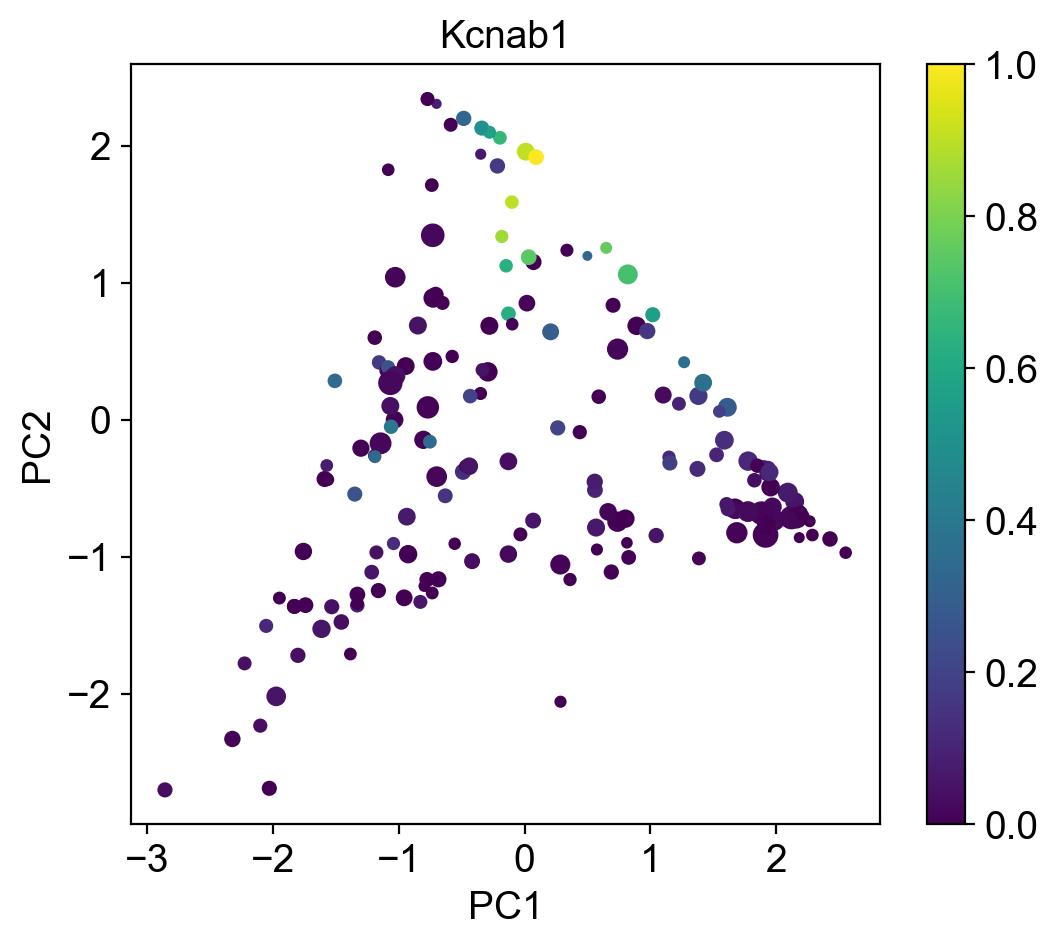

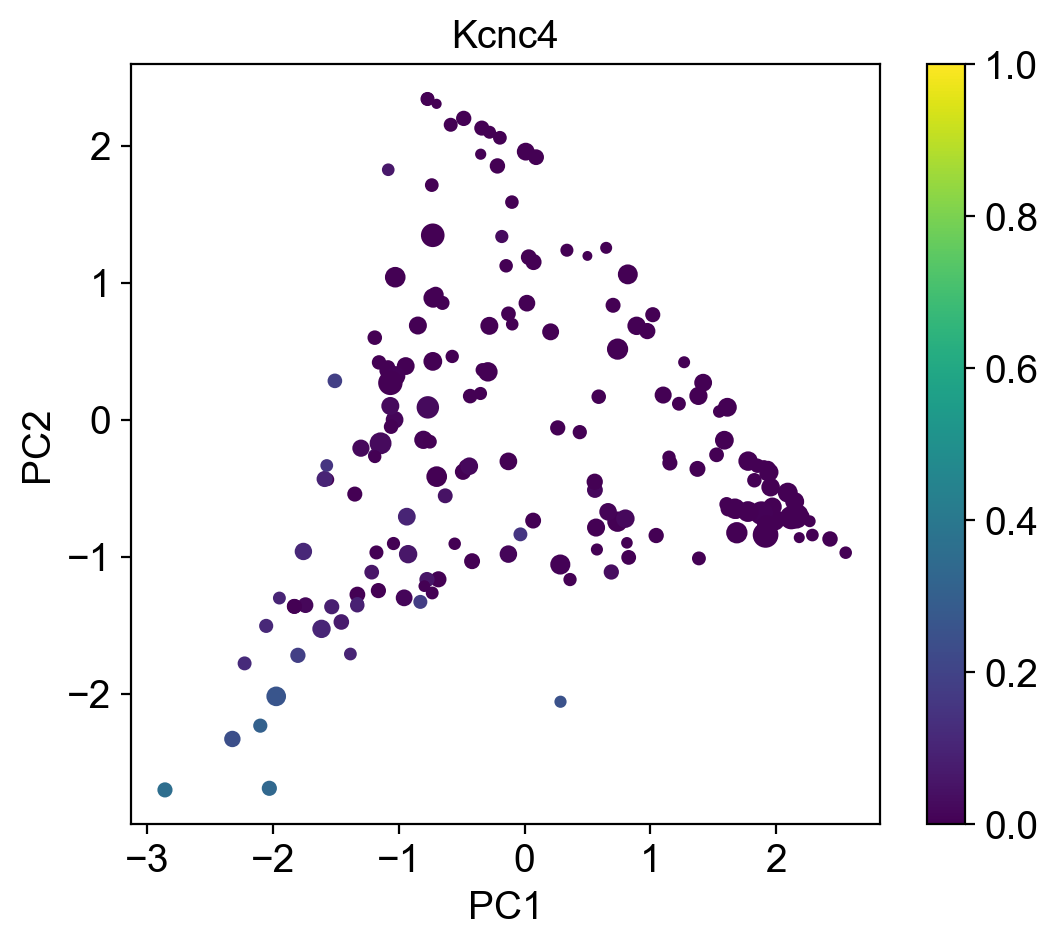

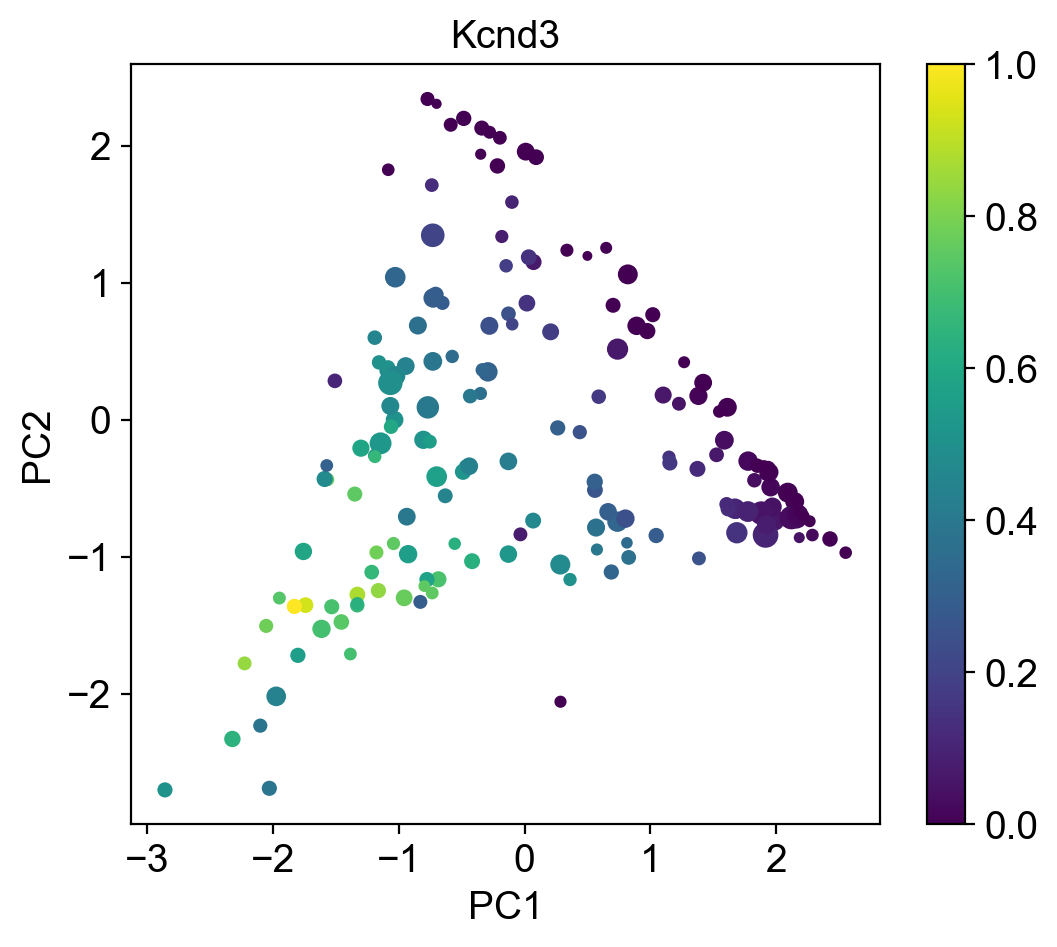

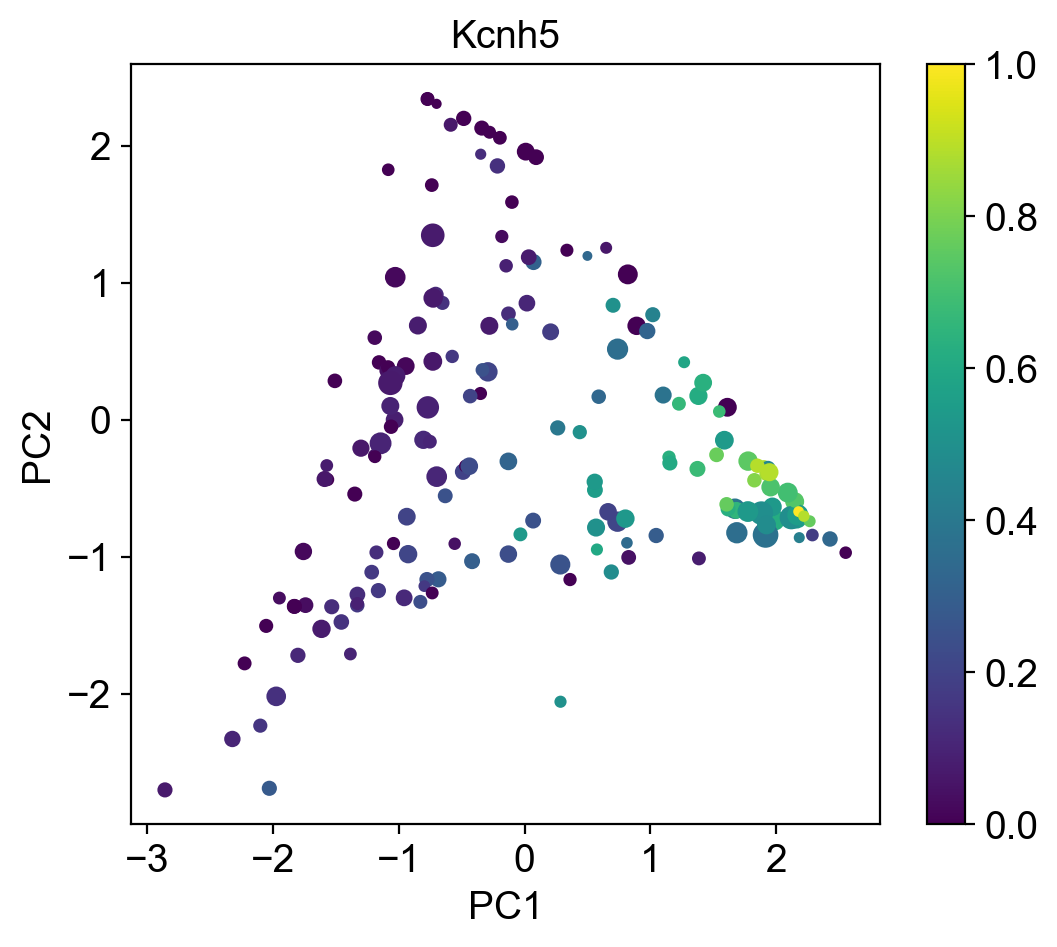

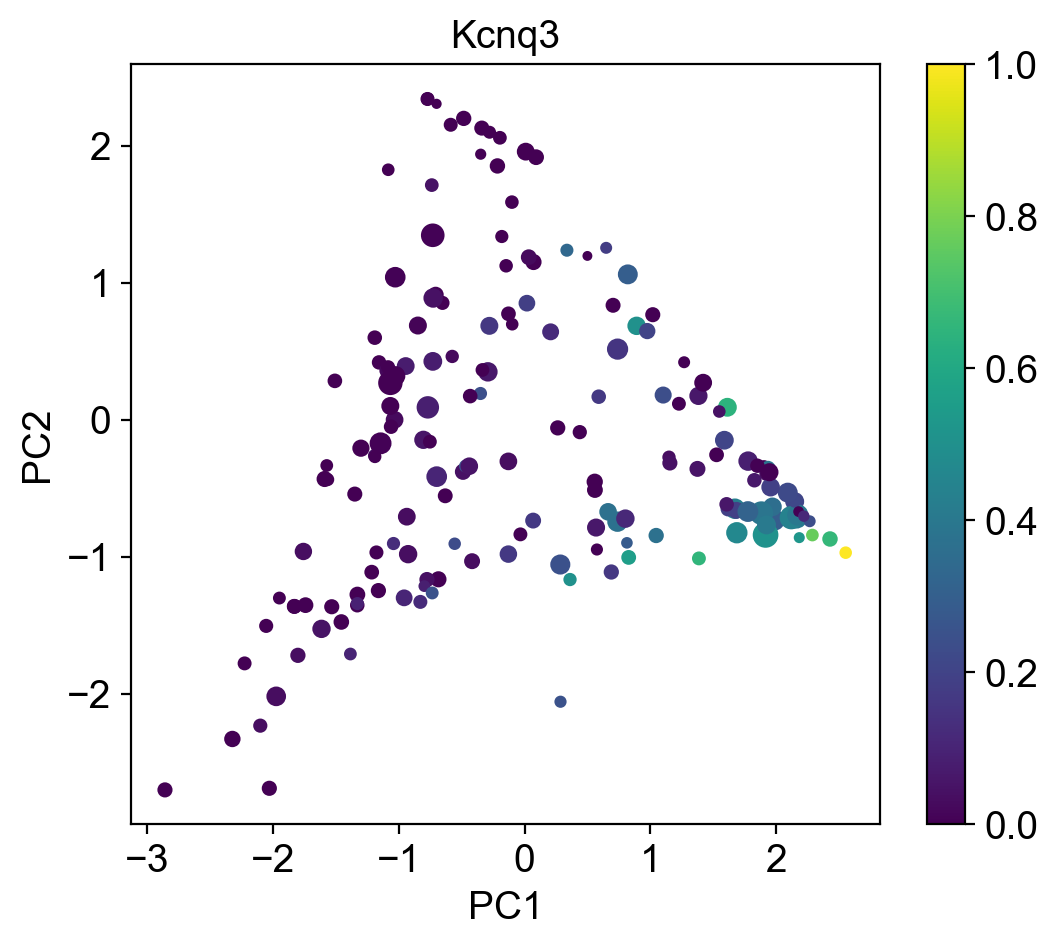

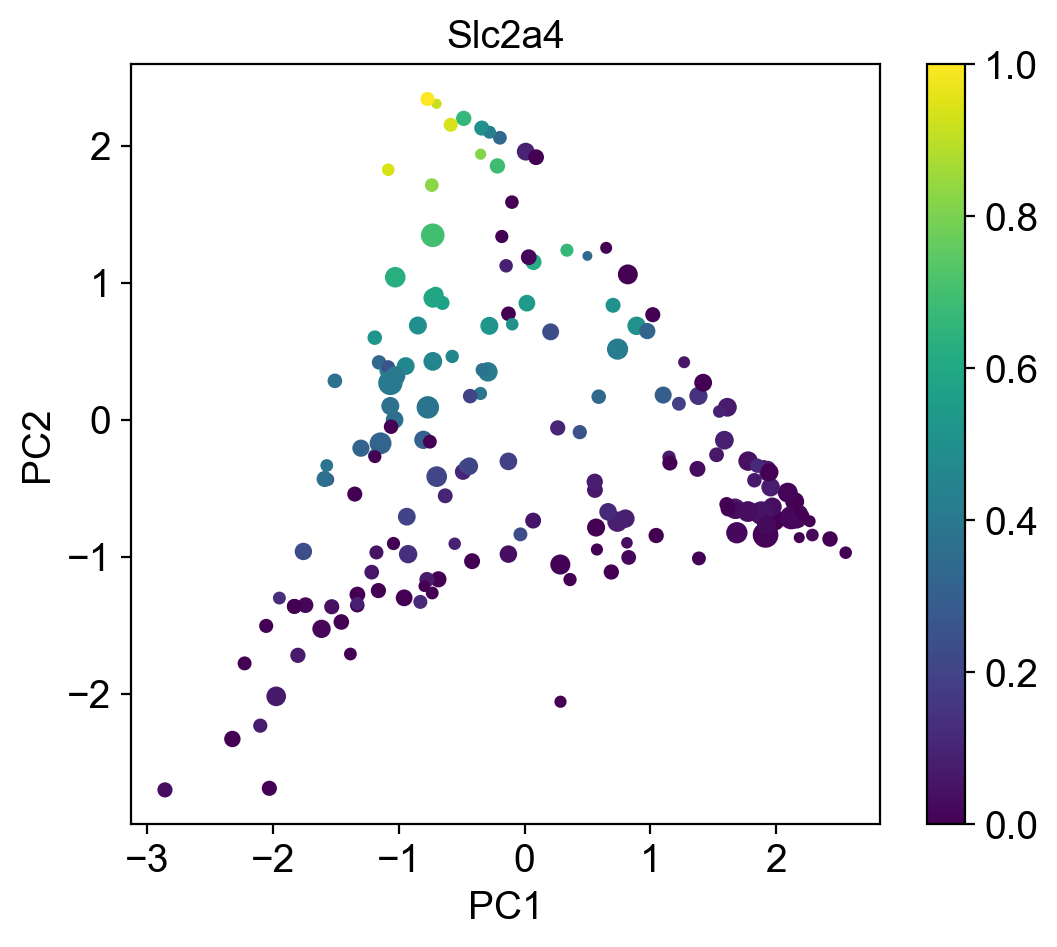

In [12]:
for g in ['Kcnab1','Kcnc4','Kcnd3','Kcnh5','Kcnq3','Slc2a4']:
    fig = plt.figure(figsize=(6, 5))
    cm = plt.cm.get_cmap('viridis')
    sc = plt.scatter(results['PC1'], results['PC2'], c=cnts[g], vmin=0, vmax=1, s=data.Area/200, cmap=cm)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(sc)
    plt.grid(False)
    plt.title(g)
    plt.show()

In [19]:
adata = sc.AnnData(cnts.iloc[:,:-1], obs=data[['Perimeter','Area','Total_counts','clusters']],
                   obsm={'X_pca':results.values[:,:-1], 'X_spatial':data[['x','y']].values, 'X_spatial_flip':data[['x','y_flip']].values}
                   )
adata.obs_names = 'cell' + '_' + adata.obs_names.astype(str)
adata.obs.clusters = adata.obs.clusters.astype(str)
adata.write_h5ad('Results_h5ad/03_Hiplex.h5ad', compression='gzip')

/Users/pax/miniconda3/envs/vestibular/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [14]:
adata = sc.read_h5ad('Results_h5ad/03_Hiplex.h5ad')
adata = adata[adata.X.sum(1) > 0].copy()

In [15]:
adata

AnnData object with n_obs × n_vars = 191 × 5
    obs: 'Perimeter', 'Area', 'Total_counts', 'clusters'
    obsm: 'X_pca', 'X_spatial', 'X_spatial_flip'